In [1]:
#import
from pandapower_env.environments.simulation_env import (
    PPTopoGym,
)
from gymnasium import spaces
import torch
import numpy as np
import copy

from pandapower_env.data.example_configs import config_case30
from pandapower_env.agents.benchmark_agents import (
    DoNothingAgent,
    GreedyAgent,
    RandomAgent,
)

import sys
import os
import warnings
import logging
from IPython.core.interactiveshell import InteractiveShell

# Suppress warnings
warnings.simplefilter("ignore")

# Suppress logging
logging.getLogger().setLevel(logging.CRITICAL)

# Suppress auto-output of expressions in Jupyter cells
InteractiveShell.ast_node_interactivity = "none"


class SuppressOutput:
    def __enter__(self):
        self._stdout = sys.stdout
        self._stderr = sys.stderr
        sys.stderr = open(os.devnull, "w")  # Suppress stderr

        class PrintFilter:
            def __init__(self, original_stdout):
                self._stdout = original_stdout
                self._needs_newline = False  # Tracks if a newline is needed

            def write(self, message):
                if message.strip():  # Ignore empty messages
                    if self._needs_newline:
                        self._stdout.write("\n")  # Ensure a new line before printing
                    self._stdout.write(message)
                    self._needs_newline = not message.endswith(
                        "\n"
                    )  # Track if new line is needed

            def flush(self):
                self._stdout.flush()

        self._filter = PrintFilter(self._stdout)
        sys.stdout = self._filter  # Redirect stdout through filter

    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stderr.close()  # Close stderr redirection
        sys.stderr = self._stderr  # Restore stderr
        sys.stdout = self._stdout  # Restore stdout

In [2]:
#config
my_config = config_case30()
actions = spaces.Discrete(len(my_config["action_space"]))
index = 96*90  #96*70

NameError: name 'add_actions_substation_line_switching' is not defined

[]


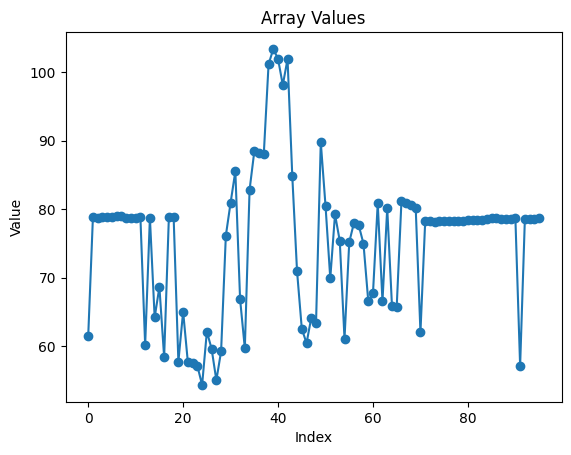

In [3]:
#DoNothing Agent + Plot
config = copy.deepcopy(my_config)
env = PPTopoGym(config)
obs, info = env.reset(options={"index": index})
agent_dn = DoNothingAgent(actions)
overloads = []
overloads_net = []
with SuppressOutput():
    for _ in range(96):
        action = agent_dn.act(obs)
        obs, reward, terminated, truncated, info = env.step(action)
        overloads_net.append(round(float(env.net.res_line.loading_percent.max()),2))
print(overloads)

# plot
import matplotlib.pyplot as plt
plt.plot(overloads_net, marker='o')  # marker optional
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Array Values")
plt.show()

[]


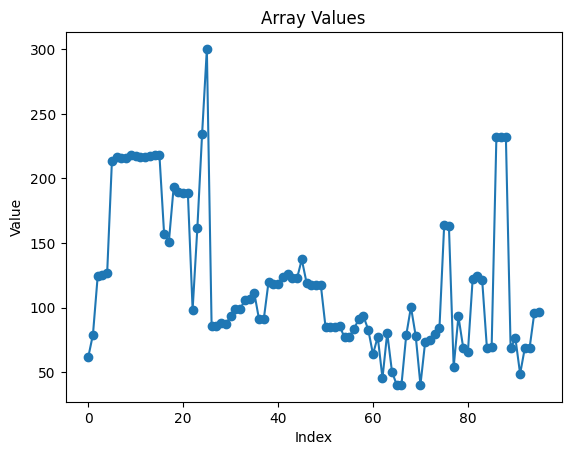

In [5]:
#RandomAgent + Plot
config = copy.deepcopy(my_config)
env = PPTopoGym(config)
obs, info = env.reset(options={"index": index})
agent_dn = RandomAgent(actions)
overloads = []
overloads_net = []
with SuppressOutput():
    for _ in range(96):
        action = agent_dn.act(obs)
        obs, reward, terminated, truncated, info = env.step(action)
        overloads_net.append(round(float(env.net.res_line.loading_percent.max()),2))
print(overloads)

# plot
import matplotlib.pyplot as plt
plt.plot(overloads_net, marker='o')  # marker optional
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Array Values")
plt.show()

Net did not converge.
Power flow did not converge at creating an observation at step 8
NoneType: None
Power flow did not converge in simulation at step 8
NoneType: None
Net did not converge.
Power flow did not converge at creating an observation at step 8
NoneType: None
Power flow did not converge in simulation at step 8
NoneType: None
Net did not converge.
Power flow did not converge at creating an observation at step 20
NoneType: None
Power flow did not converge in simulation at step 20
NoneType: None
Net did not converge.
Power flow did not converge at creating an observation at step 25
NoneType: None
Net did not converge.
Power flow did not converge in simulation at step 25
NoneType: None
Power flow did not converge at creating an observation at step 25
NoneType: None
Power flow did not converge in simulation at step 25
NoneType: None
Net did not converge.
Power flow did not converge at creating an observation at step 26
NoneType: None
Net did not converge.
Power flow did not conve

[]


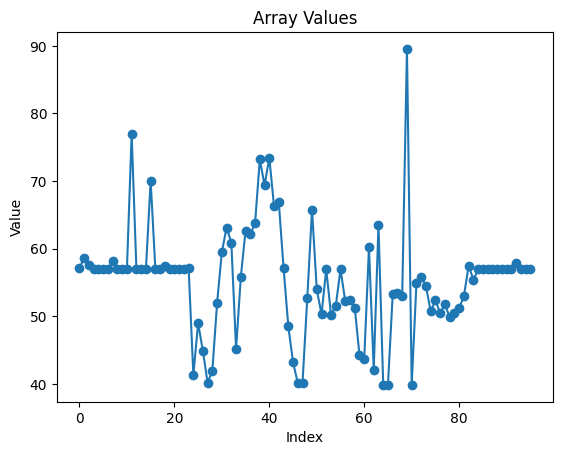

In [6]:
#GreedyAgent + Plot
config = copy.deepcopy(my_config)
config_agent = copy.deepcopy(my_config)
env = PPTopoGym(config)
obs, info = env.reset(options={"index": index})
agent_dn = GreedyAgent(actions, config_agent, n_workers=16)
overloads = []
overloads_net = []
with SuppressOutput():
    for _ in range(96):
        action = agent_dn.act(obs, info)
        obs, reward, terminated, truncated, info = env.step(action)
        overloads_net.append(round(float(env.net.res_line.loading_percent.max()),2))
print(overloads)

# plot
import matplotlib.pyplot as plt
plt.plot(overloads_net, marker='o')  # marker optional
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Array Values")
plt.show()